In [67]:
import pandas as pd
import csv
import random

bets = []

with open ('4-6-2023.csv', 'r') as f:
    csvreader = csv.reader(f)
    next(csvreader)
    for row in csvreader:
        try:
            bets.append({'odds': float(row[8]), 'clv': float(row[9]), 'stake': float(row[10]), 'payout': float(row[11]), 'bet_type': row[13]})
        except ValueError:
            pass

In [68]:
bets

[{'odds': 150.0,
  'clv': 133.0,
  'stake': 15.0,
  'payout': 37.5,
  'bet_type': 'positive_ev'},
 {'odds': 105.0,
  'clv': 115.0,
  'stake': 30.0,
  'payout': 61.5,
  'bet_type': 'positive_ev'},
 {'odds': 105.0,
  'clv': 110.0,
  'stake': 12.0,
  'payout': 24.6,
  'bet_type': 'positive_ev'},
 {'odds': -110.0,
  'clv': -115.0,
  'stake': 22.0,
  'payout': 42.0,
  'bet_type': 'positive_ev'},
 {'odds': 115.0,
  'clv': 109.0,
  'stake': 15.0,
  'payout': 32.25,
  'bet_type': 'positive_ev'},
 {'odds': 140.0,
  'clv': 132.0,
  'stake': 66.59,
  'payout': 159.82,
  'bet_type': 'arbitrage'},
 {'odds': -125.0,
  'clv': -132.0,
  'stake': 88.79,
  'payout': 159.82,
  'bet_type': 'arbitrage'},
 {'odds': -118.0,
  'clv': 101.0,
  'stake': 4.95,
  'payout': 9.14,
  'bet_type': 'arbitrage'},
 {'odds': 120.0,
  'clv': -101.0,
  'stake': 4.16,
  'payout': 9.15,
  'bet_type': 'arbitrage'},
 {'odds': -190.0,
  'clv': -178.0,
  'stake': 2.46,
  'payout': 3.75,
  'bet_type': 'arbitrage'},
 {'odds': 200.0

In [47]:
def american_to_percent (american):
    if american > 0:
        return 100 / (100 + american)
    else:
        return -american / (100 - american)

In [69]:
import random

# 0: american
# 1: implied odds
# 2: bet amount
# 3: payout
# 5: bet type

def sim(bets):
    bankroll = 0
    for bet in bets:
        if bet['bet_type'] != "positive_ev":
            continue
        try:
            prob = american_to_percent(float(bet['clv']))
        except ValueError:
            print(bet)
            continue
        rand = random.random()
        if rand < prob:
            bankroll += float(bet['payout']) - float(bet['stake'])
        else:
            bankroll -= float(bet['stake'])
    return bankroll
    

In [49]:
# print(bets)

In [70]:
sims = sim(bets)

sims = []
for i in range(50000):
    # print(i)
    sims.append(sim(bets))

In [71]:
print(len(sims))

50000


The average bankroll is 868.0300090000002 and the median is 864.0800000000006


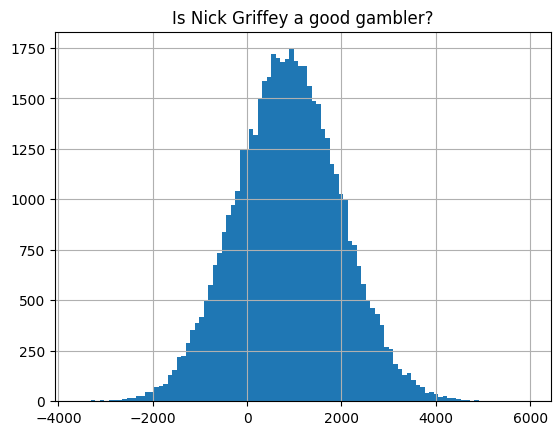

In [72]:
import matplotlib.pyplot as plt
import numpy as np

griffy = pd.DataFrame(sims)
griffy.hist(bins=100)
plt.title('Is Nick Griffey a good gambler?')
print("The average bankroll is {average} and the median is {median}".format(average=np.mean(sims), median=np.median(sims)))